# Kaggle – Data on the top
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: RMSE

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Donde $y_i$ es el valor real y $\hat{y}_i$ es el valor predicho. **Cuanto menor, mejor.**

---
# PARTE 1: Entrenamiento del modelo

## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from toolbox_ml.eda.core import tipifica_variables, describe_df, verificar_dataframe

## 2. Datos

In [2]:
df = pd.read_csv('./data/train.csv', encoding='latin-1')

### 2.1 Exploración de los datos

In [3]:
# Tu código aquí
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [4]:
df.describe()

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


In [5]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
laptop_ID,int64,0.0,912,100.00
Company,str,0.0,19,2.08
Product,str,0.0,480,52.63
TypeName,str,0.0,6,0.66
Inches,float64,0.0,17,1.86
ScreenResolution,str,0.0,36,3.95
Cpu,str,0.0,107,11.73
Ram,str,0.0,9,0.99
Memory,str,0.0,37,4.06
Gpu,str,0.0,93,10.20


In [6]:
# Función de nuestro toolkit!
# Que no esté vacío
# Que no tenga duplicados
# Que no tenga nulos
# Que no tenga infinitos ni columnas constantes
verificar_dataframe(df)

The DataFrame is ready for modeling


## Estudiadas las columnas por encima (con DataWranggler)
### Procedimiento con cada una:

1. Laptop_ID: La tiro. Cada fila es única y no aporta nada (son IDs). La tendré que volver a poner al final en el test.csv porque no me dejará hacer submission o saldrá mal el score, pero la tiro.
2. Company: Se queda. Categórica de manual. Dentro del pipeline (trabajaré con él, ya no puedo "desverlo") haré un one-hot.
3. Product: En principio, la tiro. Parece una tontería, pero me explico: Las características son las que hacen al producto, no al revés. Estaría prediciendo un nombre. Aun así, probaría en algún momento a incluirla por si acaso, pero en principio no tiene cabida.
4. TypeName: Se queda. Categórica de seis valores. One-hot también en el pipeline.
5. Inches: Numérica continua. Se queda igual, sin cambios. La convertiría en categórica, pero perdería ese peso que tienen las numéricas. A mayor tamaño, mayor es el precio. Se queda así.
6. ScreenResolution: Hay que trabajar en esta. Las resoluciones me gustaría tenerlas separadas de manera numérica. Quizá haga directamente la operación de la resolución (multiplicar). Después, toca crear dos columnas binarias de 0s y 1s de IPS y Touchscreen. Pueden no tener ninguno, tener alguno de los dos o tener los dos. Queda fuera la definición de la resolución (full HD por ejemplo) por ser redundante.
7. CPU: Hay que trabajar también. Los GHZ sí o sí como columna numérica. La marca como categórica. Y luego la gama (i3, i5...) que me gustaría saber cómo categorizarlas. Quisiera hacer un ordinal encoder a mano, pero no sé bien cómo organizarlo al haber varias marcas. Lo estudiaré en su debido momento.
8. RAM: Le quito el GB y queda numérica.
9. Memory: Toca trabajar un poco con esta. Separaré en columnas numéricas del tipo: SSD_GB, HDD_GB, Flash_GB, Hybrid_GB. Pasar TB a GB para unificar todo en la misma escala. Los casos con múltiples discos duros, quedarán las dos columnas llenas: SSD_GB=256 y HDD_GB=1024. Que el modelo aprenda solito que SSD encarece más.
10. GPU: Saco la marca (intel, nvidia, AMD) y convierto eso en categórica. Las de intel serán las más baratas y luego tengo Nvidia y AMD. Lástima no tener los GB, pero tengo los modelos. Puedo trabajar en sus gamas (GTX, RTX, R5, R7...) igual que en CPU.
11. OpSys: Categórica. Hay un macOS y un MacOS X. Unifico a macOS que es el mismo sistema. Mac OS X es como se llamaba antes.
12. Weight: Le quito el KG y queda en numérica continua. Limpia.
13. Price_in_euros: Target.

In [7]:
# Como vimos en el ejemplo de clase, vamos a tener que hacer el mismo proceso dos veces
# Eso significa que lo mejor es hacerme una bonita función

def df_tc_preparado(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.drop(columns=["laptop_ID", "Product"])
    df["Ram"] = df["Ram"].str.replace("GB", "").astype(int)
    df["OpSys"] = df["OpSys"].replace({"Mac OS X": "macOS"})
    df["Weight"] = df["Weight"].str.replace("kg", "").astype(float)

    # Las dos columnas nuevas a extraer para meterlas como categorías
    df["IPS"] = df["ScreenResolution"].str.contains("IPS", case=False).astype(int)
    df["TouchScreen"] = df["ScreenResolution"].str.contains("TouchScreen", case=False).astype(int)

    # Ahora las columnas de la resolución.
    # Como no encontraba manera de extraer fácil la resolución con pandas/python, he tenido que usar magia prohibida:
    # Expresiones regulares.
    resolucion = df["ScreenResolution"].str.extract(r"(\d+)x(\d+)")
    # Después de este dolor de cabeza, extraigo ancho y alto (1920 y 1080, por ejemplo)
    ancho = resolucion[0].astype(int)
    alto = resolucion[1].astype(int)
    # Y me hago una columna nueva con los píxeles totales. En escala, esta columna representa un peso numérico
    # Porque a mayor el número, mayor el precio.
    df["pixeles_totales"] = ancho * alto
    df = df.drop(columns=["ScreenResolution"])

    # CPU
    # Extraer primero la marca y luego los GHz
    # La marca es la primera palabra siempre
    df["CPU_Marca"] = df["Cpu"].str.split().str[0]
    # El reloj es la última palabra y además hay que quitarle GHz para que quede numérica
    df["CPU_GHz"] = df["Cpu"].str.split().str[-1]
    df["CPU_GHz"] = df["CPU_GHz"].str.replace("GHz", "").astype(float)
    # Extraigo la gama con una función
    # RECUERDO: Apply hace que se ejecute la función fila a fila
    df["CPU_Gama"] = df["Cpu"].apply(extraer_gama_cpu)


    # GPU
    # Extraer primero la marca (es la primera palabra, sencillo)
    df["GPU_Marca"] = df["Gpu"].str.split().str[0]
    # Extraigo la gama con una función a mano
    df["GPU_Gama"] = df["Gpu"].apply(extraer_gama_gpu)

    # Hago cuatro columnas nuevas para el tipo de disco duro
    # Uso un apply con una función que me extrae para cada tipo de disco duro su almacenamiento
    df[["SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]] = df["Memory"].apply(extraer_memoria)

    # Hechos todos los cambios sobre estas columnas, las mandamos fuera.
    df = df.drop(columns=["Cpu", "Gpu", "Memory"])

    return df


# Función que extrae la gama del CPU a mano
# No se me ocurre otra manera en este caso particular
def extraer_gama_cpu(cpu: str):
    # Paso a minúsculas
    texto = cpu.lower()

    # Extraigo las de intel
    if "i7" in texto:
        return "Core i7"
    elif "i5" in texto:
        return "Core i5"
    elif "i3" in texto:
        return "Core i3"
    elif "i9" in texto:
        return "Core i9"
    elif "core m" in texto:
        return "Core M"
    elif "xeon" in texto:
        return "Xeon"
    elif "celeron" in texto:
        return "Celeron"
    elif "pentium" in texto:
        return "Pentium"
    elif "atom" in texto:
        return "Atom"
    # AMD (lo estoy odiando mucho por no tener una estructura tan clara como intel)
    elif "ryzen" in texto:
        return "AMD Ryzen"
    elif "e-series" in texto:
        return "AMD E-Series"
    elif "-series" in texto: # Había separado los números, pero es tontería. Reduzco a A-Series
        return "AMD A-Series"
    elif "fx" in texto:
        return "AMD FX"
    # Todo lo demás aquí
    else:
        return "Otro"
    
# Función que extrae la gama de la GPU a mano
# De nuevo, no se me ocurrió otra manera
def extraer_gama_gpu(gpu: str):
    # Paso a minúsculas
    texto = gpu.lower()

    # Extraer las gamas de nVidia
    if "rtx" in texto:
        return "RTX"
    elif "gtx" in texto:
        return "GTX"
    elif "quadro" in texto:
        return "Quadro"
    elif "mx" in texto:
        return "MX"
    elif "geforce" in texto:
        return "GeForce"
    # Extraer las gamas de AMD
    elif "rx" in texto:
        return "RX"
    elif "vega" in texto:
        return "Vega"
    elif "firepro" in texto:
        return "FirePro"
    elif "radeon" in texto:
        return "Radeon"
    # Extraer las de Intel (casi todas integradas en realidad)
    # El mayor motivo por el que hago esto. Empujarán mucho el precio hacia abajo estas
    elif "iris" in texto:
        return "Iris"
    # Error corregido: UHD primero porque HD me pillaba los UHD antes y no quedaba ninguno
    elif "uhd" in texto:
        return "UHD"
    elif "hd" in texto:
        return "HD"
    else:
        return "Otro"


# Por cada fila (el apply en la función principal) se va a extraer
# la capacidad de almacenamiento y lo va a meter en cada tipo de disco duro
def extraer_memoria(memory: str)-> pd.Series:
    ssd = 0
    hdd = 0
    flash = 0
    hybrid = 0

    memoria_separada = memory.split("+")

    for memoria in memoria_separada:
        memoria = memoria.strip()
        # La capacidad es la primera palabra (256GB, 1TB, etc)
        capacidad = memoria.split()[0]
        # La unidad son los dos ultimos caracteres (GB)
        unidad = capacidad[-2:]
        # El numero es todo menos esos dos ultimos caracteres
        numero = float(capacidad[:-2])

        # TB a GB
        if unidad == "TB":
            numero = numero * 1024
        # Con el resto me fijo de qué tipo es y se suma número
        if "SSD" in memoria:
            ssd = ssd + numero
        elif "HDD" in memoria:
            hdd = hdd + numero
        elif "Flash" in memoria:
            flash = flash + numero
        elif "Hybrid" in memoria:
            hybrid = hybrid + numero

    return pd.Series([ssd, hdd, flash, hybrid], index=["SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"])

### COMPROBACIÓN DE LA FUNCIÓN:
Compruebo que la función que he hecho arriba funciona y me devuelve un DataFrame como el que busco para trabajar antes de hacerlo en el split

In [8]:
df_comprobacion = df_tc_preparado(df)
df_comprobacion

,Company,TypeName,Inches,Ram,OpSys,Weight,Price_in_euros,IPS,TouchScreen,pixeles_totales,CPU_Marca,CPU_GHz,CPU_Gama,GPU_Marca,GPU_Gama,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB
0,HP,Notebook,15.6,8,Windows 10,1.86,539.00,0,0,2073600,Intel,2.0,Core i3,Intel,HD,256.0,0.0,0.0,0.0
1,Dell,Gaming,15.6,16,Windows 10,2.59,879.01,0,0,2073600,Intel,2.6,Core i7,Nvidia,GTX,0.0,1024.0,0.0,0.0
2,HP,Notebook,15.6,8,Windows 10,2.04,900.00,0,0,2073600,Intel,2.7,Core i7,Nvidia,MX,0.0,1024.0,0.0,0.0
3,Apple,Ultrabook,13.3,8,macOS,1.34,898.94,0,0,1296000,Intel,1.8,Core i5,Intel,HD,0.0,0.0,128.0,0.0
4,Dell,Notebook,15.6,4,Linux,2.25,428.00,0,0,2073600,Intel,2.0,Core i3,AMD,Radeon,0.0,1024.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,Dell,Notebook,15.6,8,Windows 10,2.20,800.00,0,0,2073600,Intel,1.6,Core i5,AMD,Radeon,256.0,0.0,0.0,0.0
908,HP,2 in 1 Convertible,13.3,8,Windows 10,1.48,1629.00,0,1,2073600,Intel,2.4,Core i5,Intel,HD,256.0,0.0,0.0,0.0
909,Lenovo,Notebook,15.6,8,No OS,2.20,519.00,0,0,2073600,Intel,2.5,Core i5,Intel,HD,0.0,2048.0,0.0,0.0
910,HP,Notebook,15.6,4,No OS,1.86,258.00,0,0,1049088,AMD,1.5,AMD E-Series,AMD,Radeon,0.0,500.0,0.0,0.0


In [9]:
df_comprobacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Company          912 non-null    str    
 1   TypeName         912 non-null    str    
 2   Inches           912 non-null    float64
 3   Ram              912 non-null    int64  
 4   OpSys            912 non-null    str    
 5   Weight           912 non-null    float64
 6   Price_in_euros   912 non-null    float64
 7   IPS              912 non-null    int64  
 8   TouchScreen      912 non-null    int64  
 9   pixeles_totales  912 non-null    int64  
 10  CPU_Marca        912 non-null    object 
 11  CPU_GHz          912 non-null    float64
 12  CPU_Gama         912 non-null    str    
 13  GPU_Marca        912 non-null    object 
 14  GPU_Gama         912 non-null    str    
 15  SSD_GB           912 non-null    float64
 16  HDD_GB           912 non-null    float64
 17  Flash_GB         912 non-nu

In [10]:
tipifica_variables(df_comprobacion)

,nombre_variable,tipo_sugerido
0,Company,Numérica Discreta
1,TypeName,Categórica
2,Inches,Numérica Discreta
3,Ram,Categórica
4,OpSys,Categórica
5,Weight,Numérica Discreta
6,Price_in_euros,Numérica Discreta
7,IPS,Binaria
8,TouchScreen,Binaria
9,pixeles_totales,Categórica


In [11]:
df_comprobacion.GPU_Gama.value_counts()

GPU_Gama
HD         444
GTX        171
Radeon     103
MX          84
UHD         52
Quadro      19
Iris        12
RX          10
GeForce     10
FirePro      4
Otro         3
Name: count, dtype: int64

### 2.2 Definir X e y


In [12]:
# Tu código aquí
df_preparado = df_tc_preparado(df)

X = df_preparado.drop(columns=["Price_in_euros"])
y = df_preparado["Price_in_euros"]

### 2.3 Dividir en train y test

In [13]:
# Tu código aquí
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_test.shape)
print(X_train.shape)

(183, 18)
(729, 18)


## 3. Procesado de datos

> 🚨 **Data leakage:** si usas un scaler, haz **`.fit()` SOLO sobre `X_train`** y luego aplica `.transform()` sobre `X_train` y `X_test` por separado.
>
> Recuerda también que **todo lo que hagas aquí deberás replicarlo después en `test.csv`** (sección 6).

In [14]:
# Tu código aquí
features_cat = ["Company", "TypeName", "OpSys", "CPU_Marca", "CPU_Gama", "GPU_Marca", "GPU_Gama"]
features_num = ["Inches", "Ram", "Weight", "CPU_GHz", "pixeles_totales", "SSD_GB", "HDD_GB", "Flash_GB", "Hybrid_GB"]

In [15]:
# Como en otros ejercicios, usaré Pipelines y un par de cosas más que le vienen bien
# O que, mejor dicho, son prácticamente obligatorias, como este ColumnTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Me hubiese gustado NO usar un OneHotEncoder en todas, sino un OrdinalEncoder
# para algunas de las categóricas como CPU_gama y GPU_Gama
# El problema: Por mucho que investigue el orden de "peso" de estas categorías
# me estaría fijando en el precio para ver cuál pesa más o menos.
# Eso es un data leakage. Igual que mirar en internet qué gamas son mejores que otras.
# Al final le estaría diciendo al modelo cómo estudiar las cosas que no debería saber.
# Plus: Es una función complicada y ya hice bastantes.

# el "ignore" es por si en test no hay alguna de las categorías o si aparece una nueva
# Según documentación, ColumnTransformer tira todas las columnas que no se le pasen POR DEFECTO
# Con esto se evita
procesador = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)],
                                  remainder="passthrough")


## 4. Modelado

### 4.1 Entrenamiento

In [16]:
# Tu código aquí
# Como dije, PIPELINE:
from sklearn.pipeline import Pipeline
#Primero modelo un RandomForest. Terminaré usando Catboost y LightBoost, pero quiero comparar.
from sklearn.ensemble import RandomForestRegressor

pipeline_rf = Pipeline(steps=[
    ("procesador", procesador),
    ("modelo", RandomForestRegressor(random_state=42)),
])

pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('procesador', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

### 4.2 Métricas

Recuerda que en la competición se evalúa con **RMSE**.

In [17]:
# Tu código aquí
from sklearn.metrics import root_mean_squared_error

# Pipeline predice sobre X_test porque lo que hace es aplicarle el mismo procesador y el modelo
# Los mismos pasos, vaya.
y_pred = pipeline_rf.predict(X_test)


rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

RMSE: 330.8276926794352


OPINIONES: Muy contento con este primer resultado sin apenas haber usado hiperparámetros ni nada.  
Esperaba al menos un RMSE de 400 o algo más.  

Ahora, a retocar algunas cosas, elegir el modelo definitivo y por último la optimización.

#### MINI-EDA

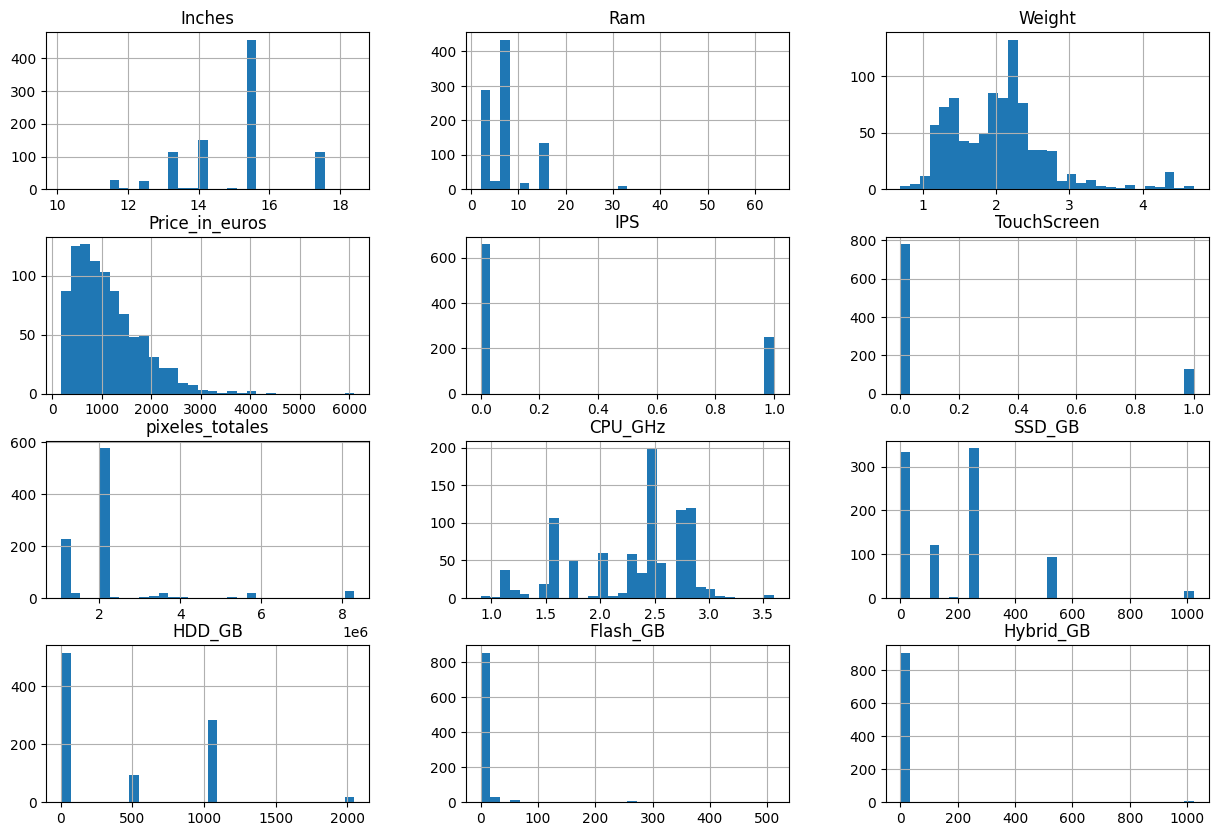

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Me había dejado las visualizaciones o el MINIEDA para esta parte a propósito
# He buscado influenciarme CERO (casi cero) con cómo se ven los datos antes del primer modelado "bobo" como base.
# Trabajo mejor así. No tiene otra explicación.
# Al final esto es cosa de estilos.

df_preparado.hist(figsize=(15, 10), bins=30)
plt.show()

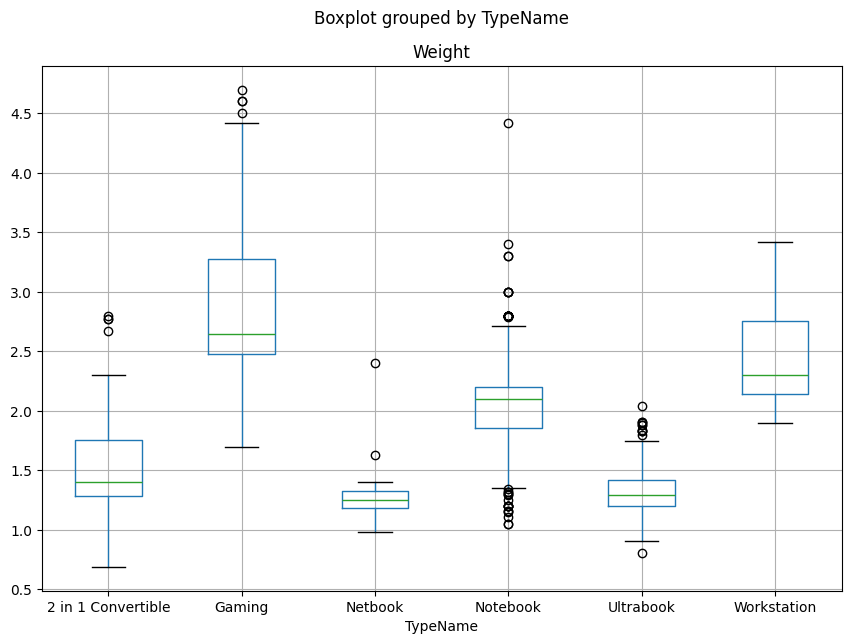

In [19]:
# por suerte, sé de ordenadores y puedo comprobar esto que es algo esperable
# Que Weight y TypeName están bastante relacionados.
# Si no supiera de ordenadores, haría una nueva clasificación entre ligeros y pesados
# Pero luego encontraría una correlación altísima (o colinearidad?) con esa nueva columna.

# Lo muestro igualmente
df_preparado.boxplot(column="Weight", by="TypeName", figsize=(10,7))
plt.show()

In [20]:
# Quitando esa parte última, lo importante del minieda es normalizar la columna de precio
# Porque está bastante sesgada hacia la derecha.

y_train_log = np.log1p(y_train)

# Se entrena el pipeline sobre el precio normalizado. Importantísimo.
pipeline_rf.fit(X_train, y_train_log)

# PUNTO IMPORTANTE
# Me estaba volviendo loco con un RMSE de 1358 hasta que vi que era por culpa del logaritmo
# Hay que invertirlo otra vez. Es decir, se entrena con el log y luego la y_pred tiene que tener los datos normales
y_pred_log = pipeline_rf.predict(X_test)
# Gracias StackOverflow por la respuesta. Para invertir el logaritmo, np.exp
y_pred = np.exp(y_pred_log)

# RMSE
rmse_log = root_mean_squared_error(y_test, y_pred)
print("RMSE con log:", rmse_log)

RMSE con log: 323.7879164935309


Contento con este RMSE. Ahora toca probar CatBoost. Hay mucha categórica entre las features, a ver qué tal funciona.

In [21]:
# Cosas interesantes de CatBoost (esto es culpa de que Iván lo recomendase en una clase):
# El One-Hot no es necesario. Le puedes pasar las categóricas en bruto (siempre que estén bien) porque
# por detrás ya se encarga él solito de hacer la codificación y ordenarlo todo.
# No puede tener ni una sola fila con nulos y deben ser SIEMPRE de tipo string.
# Toca forzar para esto último por si acaso.
# Es bastante tardón.

from catboost import CatBoostRegressor

features_cat = ["Company", "TypeName", "OpSys", "CPU_Marca", "CPU_Gama", "GPU_Marca", "GPU_Gama"]

# cat_features es donde le pasas las categóricas. Maravilla.
modelo_catboost = CatBoostRegressor(verbose=0, cat_features=features_cat, random_state=42)

modelo_catboost.fit(X_train, y_train_log)

# Lo mismo del log de arriba en lo del precio
y_pred_cat_log = modelo_catboost.predict(X_test)
y_pred_cat = np.exp(y_pred_cat_log)

# RMSE
rmse_catboost = root_mean_squared_error(y_test, y_pred_cat)
print("RMSE CatBoost:", rmse_catboost)

RMSE CatBoost: 297.6210006384425


Victoria para CatBoost.  
Hora de optimizarlo para ver hasta dónde se puede llegar.

### 4.3 Optimización (up to you 🫰🏻)

In [22]:
# Optimización del Catboost
modelo_catboost_op = CatBoostRegressor(random_state=42, verbose=0, cat_features=features_cat, iterations=500, depth=6, learning_rate=0.05)

modelo_catboost_op.fit(X_train, y_train_log)

# Gracias otra vez StackOverflow por indicarme solo un poquito más abajo de la misma página
# que para log1p lo correcto es invertirlo con expm1
y_pred_log = modelo_catboost_op.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE CatBoost Optimizado:", rmse)


RMSE CatBoost Optimizado: 298.33882398324073


No pasa nada, no iba a hacer pleno en el RMSE con unos hiperparámetros a mano.  
Toca probar el famoso bayesiano con Optuna.  

In [27]:
import optuna
from sklearn.model_selection import cross_val_score
from catboost import Pool, cv



# No voy a mentir, esto está sacado casi todo directamente de internet
# Es un poco locura cómo funciona, pero va a través de una función
# Lo cual me parece MARAVILLOSO porque te permite jugar mucho más que cualquier otra cosa.
# Sobre todo porque, con conocimiento, podríamos debugging o mejor aún
# meter más funciones o mejorar el algoritmo.

# Antes, unos params para el modelo que van a ser "fijos"
# CASI TODA LA CASILLA ESTA SALE DE: https://www.youtube.com/watch?v=2JuzqVbjSKU
params_base = {
    "loss_function": "RMSE",
    "random_state": 42,
    "verbose": False,
    "allow_writing_files": False,
}

# Función para el crossvalidation INTERNO de CatBoost
def evaluar_modelo(params):
    # Necesario esta cosa nueva llamada "Pool"
    # es el formato de datos de CatBoost. Le pasas features, target y las categóricas.
    # Con Pool se guarda todo eso. Lo podría haber usado antes, pero no fue hasta ahora que lo vi en un vídeo de YT
    # Esto se usa para el CV interno del propio CatBoost
    pool = Pool(X_train, y_train_log, cat_features=features_cat)
    # Cosa curiosa: El verbose=0 no funcionaba. Tampoco en false. Me hablaba de cada fold. Con logging_level="Silent" ya se calla.
    resultados = cv(pool, params, fold_count=5, seed=42, logging_level="Silent")
    return resultados["test-RMSE-mean"].min()

# Y ahora la función "objetivo"
def objective(trial):
    params = dict(params_base) # Los fijos de arriba
    params["iterations"] = trial.suggest_int("iterations", 200, 1500) # iterations tendrá un int con ese nombre de la función y en ese rango. Del resto se encarga el algoritmo.
    params["depth"] = trial.suggest_int("depth", 4, 10)
    params["learning_rate"] = trial.suggest_float("learning_rate", 0.01, 0.3, log=True) # Aquí por ejemplo un float
    return evaluar_modelo(params)

## IMPORTANTÍSIMO ##
# A diferencia del vídeo de YT, aquí no tengo que hacer el modelo (aún)
# PORQUE YA LO HACE EL POOL. El Pool es el propio CatBoost
# Luego ya para sacar el modelo final con los parámetros que me diga el bayesian, sí, ahí sí

# Esto es el bayesian. Se crea un estudio, se dice la dirección (RMSE bajo, por tanto Minimize)
# Y luego el número de veces que va a lanzar el algoritmo para luego aprender de él y lanzarse otra vez
# Eso son los trials.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Mejor RMSE:", study.best_value)
print("Mejores parametros:", study.best_params)

[I 2026-06-27 12:22:13,080] A new study created in memory with name: no-name-3f4af1c5-ba56-4454-926c-9116a84536a0
[I 2026-06-27 12:22:35,577] Trial 0 finished with value: 0.36193085549102444 and parameters: {'iterations': 272, 'depth': 9, 'learning_rate': 0.019147824241018883}. Best is trial 0 with value: 0.36193085549102444.
[I 2026-06-27 12:23:30,173] Trial 1 finished with value: 0.23911884316344265 and parameters: {'iterations': 1121, 'depth': 5, 'learning_rate': 0.176744234465681}. Best is trial 1 with value: 0.23911884316344265.
[I 2026-06-27 12:25:13,804] Trial 2 finished with value: 0.24342322458394144 and parameters: {'iterations': 1341, 'depth': 7, 'learning_rate': 0.04880465193098104}. Best is trial 1 with value: 0.23911884316344265.
[I 2026-06-27 12:25:57,212] Trial 3 finished with value: 0.2629442501040845 and parameters: {'iterations': 780, 'depth': 6, 'learning_rate': 0.011665614453720444}. Best is trial 1 with value: 0.23911884316344265.
[I 2026-06-27 12:26:41,595] Trial

Mejor RMSE: 0.21130035064708536
Mejores parametros: {'iterations': 380, 'depth': 4, 'learning_rate': 0.218339453685305}


In [29]:
# FIN DEL OPTUNA
# Aplico los parámetros que salieron y a entrenar
modelo_final = CatBoostRegressor(iterations= 380, depth= 4, learning_rate= 0.218339453685305, loss_function="RMSE", random_state=42, verbose=0, cat_features=features_cat)

modelo_final.fit(X_train, y_train_log)

y_pred_log = modelo_final.predict(X_test)
y_pred = np.expm1(y_pred_log)

# RMSE
rmse_final = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse_final)

RMSE: 292.58908593606344


### FIN DEL PRIMER MODELO
Satisfecho con los 292.58 de RMSE con catboost y bayesian con 20 trials.  
Subiré este a Kaggle y más tarde probaré a afinar o probar distintos modelos.  

## 5. Reentrenamiento sobre todos los datos de `train.csv`

Una vez afinado el modelo, reentrenamos con **todos** los datos disponibles antes de predecir sobre `test.csv`.

> ¿Por qué? El split anterior era solo para validar localmente. Para la submission final queremos aprovechar el 100% de los datos de entrenamiento.

In [38]:
# Tu código aquí
y_log_completo = np.log1p(y)

modelo_final = CatBoostRegressor(iterations=380, depth=4, learning_rate=0.218339453685305, loss_function="RMSE", random_state=42, verbose=0, cat_features=features_cat)
modelo_final.fit(X, y_log_completo)

predicciones_log = modelo_final.predict(X_pred_procesado)
predicciones = np.expm1(predicciones_log)

---
# PARTE 2: Predicción y submission

Una vez tengas el modelo listo, toca predecir sobre `test.csv` y generar el archivo de submission.

## 6. Carga los datos de `test.csv`

In [39]:
# El test de kaggle
X_pred = pd.read_csv("./data/test.csv", encoding="latin-1")

# Como la función tira el laptop ID y es necesario, me lo guardo
ids_test = X_pred["laptop_ID"]

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [36]:
predicciones_log = modelo_final.predict(X_pred_procesado)
predicciones = np.expm1(predicciones_log)

submission = pd.DataFrame({
    "laptop_ID": ids_test,
    "Price_in_euros": predicciones,
})

## 7. Replica el procesado en `test.csv`

> ⚠️ Usa `.transform()`, **nunca `.fit_transform()`** sobre los datos de test.
>
> Lo único que **no puedes hacer** es eliminar filas.

In [40]:
# Tu código aquí
X_pred_procesado = df_tc_preparado(X_pred)

In [41]:
X_pred_procesado.head()

,Company,TypeName,Inches,Ram,OpSys,Weight,IPS,TouchScreen,pixeles_totales,CPU_Marca,CPU_GHz,CPU_Gama,GPU_Marca,GPU_Gama,SSD_GB,HDD_GB,Flash_GB,Hybrid_GB
0,Lenovo,Gaming,15.6,16,No OS,2.400,0,0,2073600,Intel,2.8,Core i7,Nvidia,GTX,512.0,0.0,0.0,0.0
1,Acer,Notebook,15.6,4,Linux,2.400,0,0,1049088,Intel,1.6,Celeron,Intel,HD,0.0,500.0,0.0,0.0
2,Lenovo,Notebook,15.6,4,No OS,1.900,0,0,1049088,Intel,2.0,Core i3,Intel,HD,0.0,1024.0,0.0,0.0
3,Dell,2 in 1 Convertible,15.6,8,Windows 10,2.191,1,1,2073600,Intel,2.5,Core i5,Intel,HD,256.0,0.0,0.0,0.0
4,HP,Notebook,14.0,4,Windows 10,1.950,0,0,2073600,Intel,2.5,Core i5,Intel,HD,256.0,0.0,0.0,0.0


## 8. Genera la submission

### 8.1 ¿Qué formato espera Kaggle?

In [42]:
sample = pd.read_csv('./data/sample_submission.csv', encoding='latin-1')
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


### 8.2 Crea tu submission

In [43]:
# Tu código aquí
submission = pd.DataFrame({
    "laptop_ID": ids_test,
    "Price_in_euros": predicciones,
})

### 8.3 Chequeador

Pásale el chequeador antes de subir a Kaggle. Si todo está bien, guardará el CSV automáticamente con un nombre único.

In [44]:
def checker(df_to_submit, sample, filename=None):
    """
    Valida que tu submission tenga la forma requerida por Kaggle.
    Si es correcta, guarda el CSV listo para subir.
    Si no, lee el mensaje de error y corrígelo.
    """
    if df_to_submit.shape != sample.shape:
        print(' Shape incorrecto.')
        print(f'   Tu submission: {df_to_submit.shape} | Esperado: {sample.shape}')
        print('   Revisa que no hayas borrado filas del test ni añadido/quitado columnas.')
        return

    if not (df_to_submit.columns == sample.columns).all():
        print(' Nombres de columnas incorrectos.')
        print(f'   Tus columnas:       {list(df_to_submit.columns)}')
        print(f'   Columnas esperadas: {list(sample.columns)}')
        return

    if not (df_to_submit['laptop_ID'] == sample['laptop_ID']).all():
        print(' Los IDs no coinciden con sample_submission. Revisa que no hayas reordenado el test.csv.')
        return

    if filename is None:
        from datetime import datetime
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'submission_{timestamp}.csv'

    df_to_submit.to_csv(filename, index=False)
    print(f" ¡Todo correcto! Submission guardada como '{filename}'. ¡A Kaggle!")

In [45]:
checker(submission, sample)

 ¡Todo correcto! Submission guardada como 'submission_20260627_125740.csv'. ¡A Kaggle!


## PRIMER SUBMIT HECHO
### PUNTUACIÓN: 305
CatBoost + Optuna con estos parámetros:
CatBoostRegressor(iterations=380, depth=4, learning_rate=0.218339453685305, loss_function="RMSE", random_state=42, verbose=0, cat_features=features_cat)

In [46]:
# Vamos a probar con más trials y mejor afinamiento en los rangos ahora que los conocemos.

def objective(trial):
    params = dict(params_base)
    params["iterations"] = trial.suggest_int("iterations", 200, 700)
    params["depth"] = trial.suggest_int("depth", 3, 6)
    params["learning_rate"] = trial.suggest_float("learning_rate", 0.05, 0.3, log=True)
    return evaluar_modelo(params)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=45)

print("Mejor RMSE (log):", study.best_value)
print("Mejores params:", study.best_params)

[I 2026-06-27 13:06:09,542] A new study created in memory with name: no-name-d6b9d9bc-1764-417d-a914-2576a4c40520
[I 2026-06-27 13:06:29,918] Trial 0 finished with value: 0.21429126389889008 and parameters: {'iterations': 499, 'depth': 4, 'learning_rate': 0.07387319399693167}. Best is trial 0 with value: 0.21429126389889008.
[I 2026-06-27 13:06:46,340] Trial 1 finished with value: 0.20933608405336318 and parameters: {'iterations': 431, 'depth': 4, 'learning_rate': 0.11544558279487517}. Best is trial 1 with value: 0.20933608405336318.
[I 2026-06-27 13:07:05,051] Trial 2 finished with value: 0.2114037748491672 and parameters: {'iterations': 596, 'depth': 3, 'learning_rate': 0.23278274590470274}. Best is trial 1 with value: 0.20933608405336318.
[I 2026-06-27 13:07:20,412] Trial 3 finished with value: 0.20580353221411637 and parameters: {'iterations': 544, 'depth': 3, 'learning_rate': 0.13306989360413632}. Best is trial 3 with value: 0.20580353221411637.
[I 2026-06-27 13:07:41,034] Trial 4

Mejor RMSE (log): 0.20387975894424692
Mejores params: {'iterations': 667, 'depth': 4, 'learning_rate': 0.10452278346626027}


Los mejores parámetros que encontró: Mejores params: {'iterations': 667, 'depth': 4, 'learning_rate': 0.10452278346626027}